In [1]:
# ============================================================
# ANÁLISE ESPACIAL DOS INDICADORES
# ============================================================
# Projeto: Monitoramento de Vegetação — Validação PRA
# Autora: Bruna Bertini
# Data: 2026
#
# Objetivo: Analisar a distribuição espacial dos índices
#          dentro da propriedade.
# ============================================================

import rioxarray
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Configurações de exibição
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

# Configurações do matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Caminhos do projeto
BASE = Path(r"C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao")
IND_DIR = BASE / "data" / "processed" / "indices"
RESULTS_DIR = BASE / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# Cores padrão dos índices
CORES = {"NDVI": "#2ca02c", "EVI": "#1f77b4", "NDMI": "#ff7f0e"}

# Prefixo desta etapa (para padronizar nomes de arquivos)
ETAPA = "07"

print(f"BASE:        {BASE}")
print(f"ÍNDICES:     {IND_DIR}")
print(f"RESULTADOS:  {RESULTS_DIR}")
print(f"\n✓ Ambiente configurado")

BASE:        C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao
ÍNDICES:     C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\data\processed\indices
RESULTADOS:  C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

✓ Ambiente configurado


In [2]:
# ============================================================
# 1 - CARREGAR OS TRÊS ÍNDICES (MEDIANA 2020) + CORREÇÃO DO EVI
# ============================================================
# Nota: o EVI foi gerado com fill_value=0 no fundo da propriedade.
#       Aplicamos a máscara do NDVI para remover esses zeros.
#       Nenhum arquivo .tif é alterado — só a variável em memória.

import xarray as xr


def carregar_indice(caminho: Path) -> xr.DataArray:
    """Carrega um raster de índice com tratamento de erro."""
    if not caminho.exists():
        raise FileNotFoundError(f"❌ Arquivo não encontrado: {caminho}")
    with rioxarray.open_rasterio(caminho) as src:
        return src.squeeze().load()


# --- Carregar os três rasters ---
ndvi = carregar_indice(IND_DIR / "ndvi" / "ndvi_mediana_2020.tif")
evi  = carregar_indice(IND_DIR / "evi"  / "evi_mediana_2020.tif")
ndmi = carregar_indice(IND_DIR / "ndmi" / "ndmi_mediana_2020.tif")

print("=" * 80)
print("RESOLUÇÃO DOS ÍNDICES")
print("=" * 80)
print(f"\nNDVI: shape={ndvi.shape}, resolução={ndvi.rio.resolution()[0]:.1f} m, CRS={ndvi.rio.crs}")
print(f"EVI:  shape={evi.shape},  resolução={evi.rio.resolution()[0]:.1f} m, CRS={evi.rio.crs}")
print(f"NDMI: shape={ndmi.shape}, resolução={ndmi.rio.resolution()[0]:.1f} m, CRS={ndmi.rio.crs}")

# --- Alinhar grades (se necessário) ---
if ndvi.shape == evi.shape == ndmi.shape:
    print("\n✅ Todos os índices têm a MESMA grade (mesmo shape e CRS)")
    evi_aligned = evi
    ndmi_aligned = ndmi
else:
    print("\n⚠️ Grades diferentes — realinhando EVI e NDMI à grade do NDVI...")
    evi_aligned = evi.rio.reproject_match(ndvi)
    ndmi_aligned = ndmi.rio.reproject_match(ndvi)
    print(f"   NDVI: {ndvi.shape}")
    print(f"   EVI:  {evi_aligned.shape}")
    print(f"   NDMI: {ndmi_aligned.shape}")

# --- Correção do EVI: aplicar máscara do NDVI (remove zeros do fundo) ---
evi_media_antes = np.nanmean(evi_aligned.values)
evi_validos_antes = (~np.isnan(evi_aligned.values)).sum()

evi_aligned = evi_aligned.where(~np.isnan(ndvi.values))
ndmi_aligned = ndmi_aligned.where(~np.isnan(ndvi.values))

evi_media_depois = np.nanmean(evi_aligned.values)
evi_validos_depois = (~np.isnan(evi_aligned.values)).sum()

print("\n" + "=" * 80)
print("🔧 CORREÇÃO DO EVI — aplicada em memória")
print("=" * 80)
print(f"\nAntes:  {evi_validos_antes:,} pixels válidos | média = {evi_media_antes:.3f}")
print(f"Depois: {evi_validos_depois:,} pixels válidos | média = {evi_media_depois:.3f}")
print(f"\n✅ EVI alinhado à máscara do NDVI (arquivo .tif original preservado)")

RESOLUÇÃO DOS ÍNDICES

NDVI: shape=(222, 140), resolução=10.0 m, CRS=EPSG:32722
EVI:  shape=(222, 140),  resolução=10.0 m, CRS=EPSG:32722
NDMI: shape=(112, 71), resolução=20.0 m, CRS=EPSG:32722

⚠️ Grades diferentes — realinhando EVI e NDMI à grade do NDVI...
   NDVI: (222, 140)
   EVI:  (222, 140)
   NDMI: (222, 140)

🔧 CORREÇÃO DO EVI — aplicada em memória

Antes:  31,080 pixels válidos | média = 0.200
Depois: 19,358 pixels válidos | média = 0.320

✅ EVI alinhado à máscara do NDVI (arquivo .tif original preservado)


In [3]:
# ============================================================
# 2 - ESTATÍSTICAS COMPARATIVAS DOS TRÊS ÍNDICES
# ============================================================

def calcular_stats(arr, nome):
    """Calcula estatísticas descritivas de um raster."""
    vals = arr.values[~np.isnan(arr.values)]
    return {
        "Índice": nome,
        "N válidos": len(vals),
        "N NaN": arr.size - len(vals),
        "Mín": vals.min(),
        "P25": np.percentile(vals, 25),
        "Mediana": np.median(vals),
        "Média": vals.mean(),
        "P75": np.percentile(vals, 75),
        "Máx": vals.max(),
        "Desv Pad": vals.std()
    }


df_stats = pd.DataFrame([
    calcular_stats(ndvi, "NDVI"),
    calcular_stats(evi_aligned, "EVI"),
    calcular_stats(ndmi_aligned, "NDMI")
])

print("=" * 100)
print("ESTATÍSTICAS COMPARATIVAS — MEDIANA 2020")
print("=" * 100)
print(df_stats.to_string(index=False, float_format="%.3f"))

output = RESULTS_DIR / f"{ETAPA}_estatisticas_espaciais_2020.csv"
df_stats.to_csv(output, index=False)
print(f"\n✅ Salvo: {output}")

# --- Alerta sobre o EVI sem NaN ---
n_nan_evi = df_stats.loc[df_stats["Índice"] == "EVI", "N NaN"].values[0]
if n_nan_evi == 0:
    print("\n⚠️ ATENÇÃO: EVI não possui nenhum pixel NaN.")
    print("   Isso é incomum — verifique se o raster EVI foi gerado com")
    print("   preenchimento de fundo (0 ou outro valor) fora da propriedade.")
    print("   Isso pode DISTORCER as médias e correlações calculadas.")

ESTATÍSTICAS COMPARATIVAS — MEDIANA 2020
Índice  N válidos  N NaN    Mín    P25  Mediana  Média   P75   Máx  Desv Pad
  NDVI      19358  11722  0.112  0.385    0.495  0.543 0.737 0.887     0.186
   EVI      19358  11722  0.000  0.239    0.312  0.320 0.402 0.653     0.107
  NDMI      19336  11744 -0.284 -0.111   -0.032  0.017 0.168 0.425     0.174

✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_estatisticas_espaciais_2020.csv


In [4]:
# ============================================================
# 3 - CORRELAÇÃO ESPACIAL ENTRE OS ÍNDICES
# ============================================================

# Máscara de pixels válidos em TODOS os índices
mask = (~np.isnan(ndvi.values) & 
        ~np.isnan(evi_aligned.values) & 
        ~np.isnan(ndmi_aligned.values))

# Área do pixel (10 m de resolução → 0.01 ha)
res_m = ndvi.rio.resolution()[0]
area_pixel_ha = (res_m ** 2) / 10000
area_valida_ha = mask.sum() * area_pixel_ha
area_total_ha = mask.size * area_pixel_ha

print(f"Pixels válidos em todos os índices: {mask.sum():,}")
print(f"Total de pixels: {mask.size:,}")
print(f"Cobertura: {mask.sum()/mask.size*100:.1f}%")
print(f"Área válida: {area_valida_ha:.2f} ha (de {area_total_ha:.2f} ha)\n")

# Extrair valores
ndvi_flat = ndvi.values[mask]
evi_flat = evi_aligned.values[mask]
ndmi_flat = ndmi_aligned.values[mask]

# Calcular correlação (Pearson)
corr_matrix = np.corrcoef([ndvi_flat, evi_flat, ndmi_flat])

# Calcular correlação de Spearman (mais robusta a outliers)
from scipy.stats import spearmanr
rho_matrix, _ = spearmanr(np.vstack([ndvi_flat, evi_flat, ndmi_flat]), axis=1)

corr_df = pd.DataFrame(
    corr_matrix,
    index=["NDVI", "EVI", "NDMI"],
    columns=["NDVI", "EVI", "NDMI"]
)

rho_df = pd.DataFrame(
    rho_matrix,
    index=["NDVI", "EVI", "NDMI"],
    columns=["NDVI", "EVI", "NDMI"]
)

print("=" * 80)
print("MATRIZ DE CORRELAÇÃO ESPACIAL — PEARSON (pixel a pixel)")
print("=" * 80)
print(corr_df.to_string(float_format="%.3f"))

print("\n" + "=" * 80)
print("MATRIZ DE CORRELAÇÃO ESPACIAL — SPEARMAN (robusta a outliers)")
print("=" * 80)
print(rho_df.to_string(float_format="%.3f"))

# Interpretação automática
print("\n" + "=" * 80)
print("INTERPRETAÇÃO (Pearson)")
print("=" * 80)

ndvi_evi = corr_df.loc["NDVI", "EVI"]
ndvi_ndmi = corr_df.loc["NDVI", "NDMI"]
evi_ndmi = corr_df.loc["EVI", "NDMI"]


def classificar_corr(valor):
    if valor > 0.85:
        return "✅ Altíssima"
    elif valor > 0.7:
        return "✅ Alta"
    elif valor > 0.5:
        return "⚠️ Moderada"
    elif valor > 0.3:
        return "⚠️ Baixa"
    else:
        return "❌ Muito baixa"


print(f"\nNDVI × EVI:  {ndvi_evi:.3f} — {classificar_corr(ndvi_evi)}")
print(f"NDVI × NDMI: {ndvi_ndmi:.3f} — {classificar_corr(ndvi_ndmi)}")
print(f"EVI  × NDMI: {evi_ndmi:.3f} — {classificar_corr(evi_ndmi)}")

# Alerta sobre correlações suspeitas
if ndvi_ndmi > 0.9:
    print(f"\n⚠️ NOTA: correlação NDVI×NDMI = {ndvi_ndmi:.3f} é ANORMALMENTE alta.")
    print("   Na literatura, o esperado é 0.4–0.7. Verifique:")
    print("   - Autocorrelação espacial (pixels vizinhos correlacionados)")
    print("   - Bandas usadas no cálculo do NDMI")
    print("   - Presença de área homogênea dominante")

output = RESULTS_DIR / f"{ETAPA}_correlacao_2020_indices.csv"
corr_df.to_csv(output)
rho_df.to_csv(RESULTS_DIR / f"{ETAPA}_correlacao_2020_spearman.csv")
print(f"\n✅ Salvo: {output}")
print(f"✅ Salvo: {RESULTS_DIR / f'{ETAPA}_correlacao_2020_spearman.csv'}")

Pixels válidos em todos os índices: 19,336
Total de pixels: 31,080
Cobertura: 62.2%
Área válida: 193.36 ha (de 310.80 ha)

MATRIZ DE CORRELAÇÃO ESPACIAL — PEARSON (pixel a pixel)
      NDVI   EVI  NDMI
NDVI 1.000 0.907 0.945
EVI  0.907 1.000 0.865
NDMI 0.945 0.865 1.000

MATRIZ DE CORRELAÇÃO ESPACIAL — SPEARMAN (robusta a outliers)
      NDVI   EVI  NDMI
NDVI 1.000 0.933 0.937
EVI  0.933 1.000 0.893
NDMI 0.937 0.893 1.000

INTERPRETAÇÃO (Pearson)

NDVI × EVI:  0.907 — ✅ Altíssima
NDVI × NDMI: 0.945 — ✅ Altíssima
EVI  × NDMI: 0.865 — ✅ Altíssima

⚠️ NOTA: correlação NDVI×NDMI = 0.945 é ANORMALMENTE alta.
   Na literatura, o esperado é 0.4–0.7. Verifique:
   - Autocorrelação espacial (pixels vizinhos correlacionados)
   - Bandas usadas no cálculo do NDMI
   - Presença de área homogênea dominante

✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_correlacao_2020_indices.csv
✅ Salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_

✅ Gráfico salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_histogramas_comparativos_2020.png


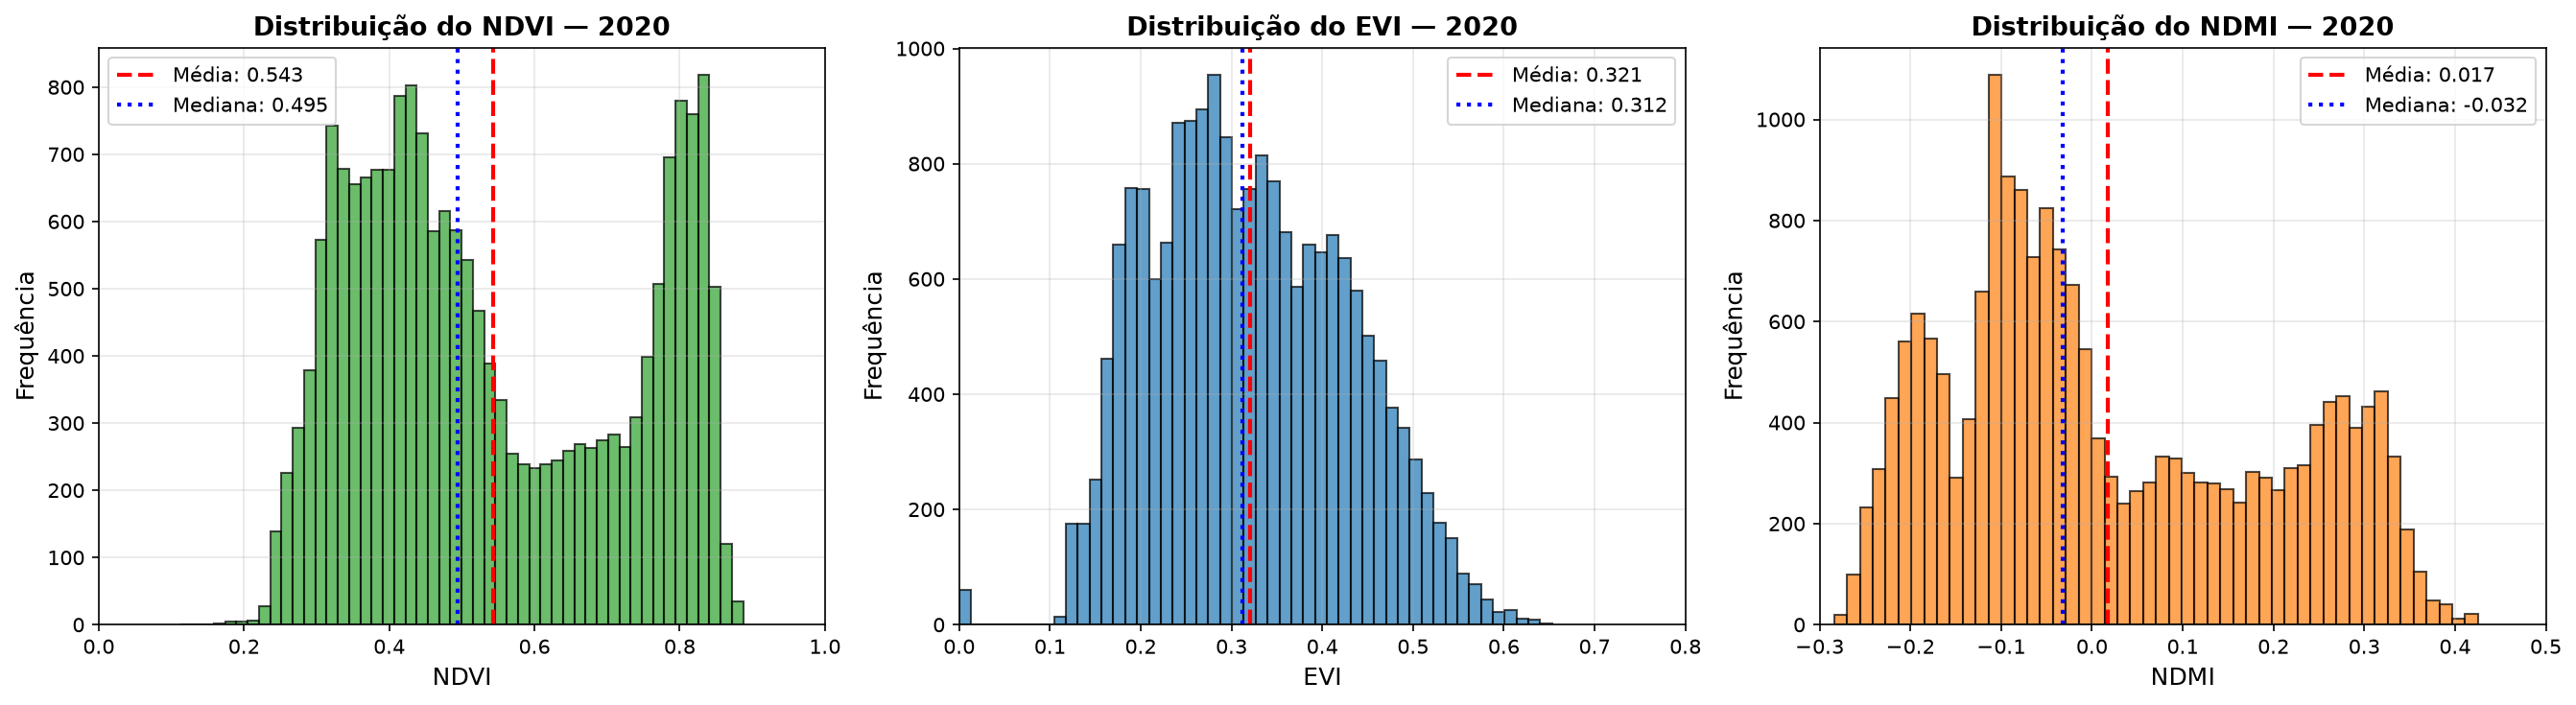

In [5]:
# ============================================================
# 4 - HISTOGRAMAS COMPARATIVOS DOS TRÊS ÍNDICES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

dados = [
    (axes[0], ndvi_flat, "NDVI", CORES["NDVI"], (0, 1)),
    (axes[1], evi_flat, "EVI", CORES["EVI"], (0, 0.8)),
    (axes[2], ndmi_flat, "NDMI", CORES["NDMI"], (-0.3, 0.5))
]

for ax, vals, nome, cor, (vmin, vmax) in dados:
    ax.hist(vals, bins=50, color=cor, alpha=0.7, edgecolor="black")
    ax.axvline(vals.mean(), color="red", linestyle="--",
               linewidth=2, label=f"Média: {vals.mean():.3f}")
    ax.axvline(np.median(vals), color="blue", linestyle=":",
               linewidth=2, label=f"Mediana: {np.median(vals):.3f}")
    ax.set_xlabel(nome, fontsize=12)
    ax.set_ylabel("Frequência", fontsize=12)
    ax.set_title(f"Distribuição do {nome} — 2020", fontsize=13, fontweight="bold")
    ax.set_xlim(vmin, vmax)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

output = RESULTS_DIR / f"{ETAPA}_histogramas_comparativos_2020.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Gráfico salvo: {output}")

plt.show()
plt.close(fig)

✅ Heatmap salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_matriz_correlacao_2020_2020.png


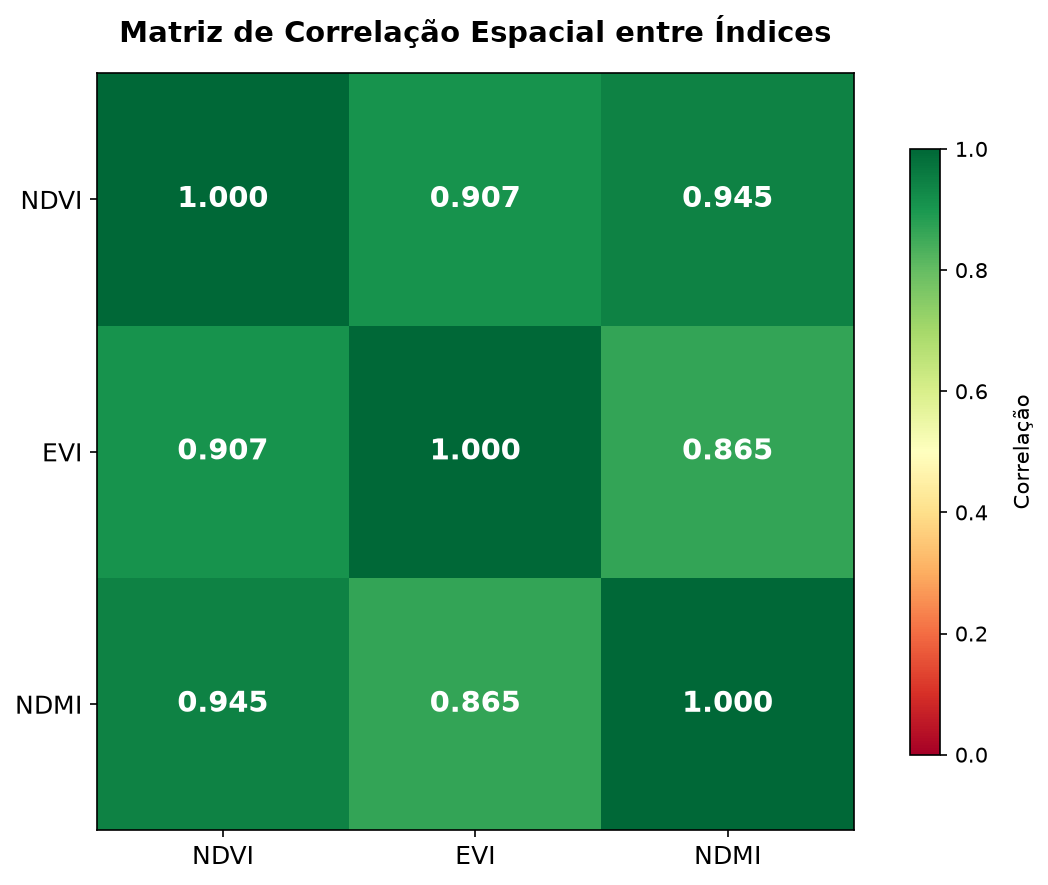

✅ Mapa salvo: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results\07_mapas_comparativos_2020.png


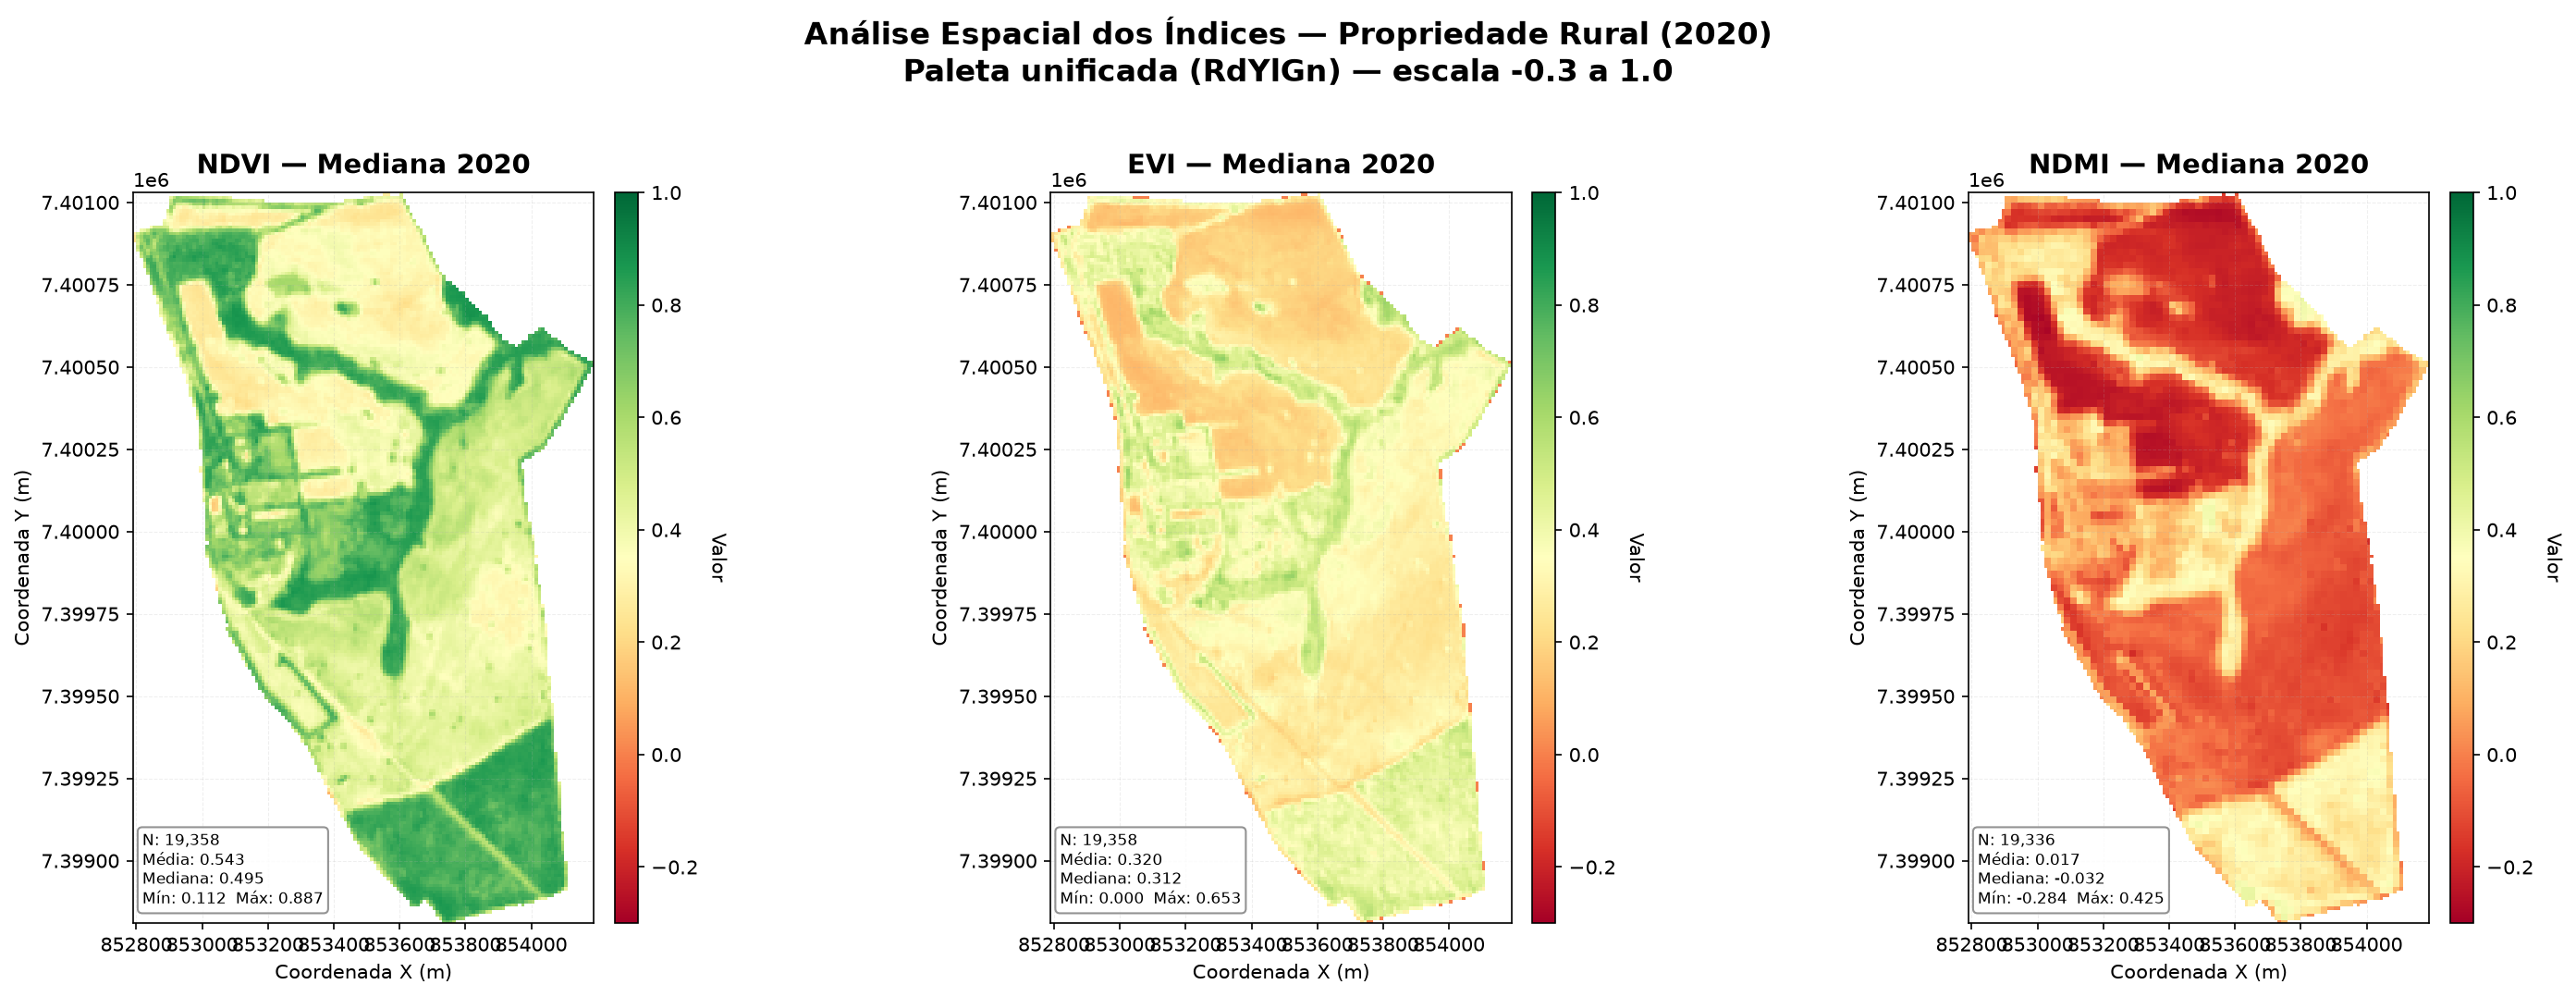

In [6]:
# ============================================================
# 5 - MATRIZ DE CORRELAÇÃO (HEATMAP) + MAPA COMPARATIVO
# ============================================================

# ------------------------------------------------------------
# 5a - HEATMAP DA MATRIZ DE CORRELAÇÃO
# ------------------------------------------------------------
labels = list(corr_df.columns)
n = len(labels)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

im = ax.imshow(corr_matrix, cmap="RdYlGn", vmin=0, vmax=1)

for i in range(n):
    for j in range(n):
        texto = f"{corr_matrix[i, j]:.3f}"
        cor_texto = "white" if corr_matrix[i, j] > 0.7 else "black"
        ax.text(j, i, texto, ha="center", va="center",
                color=cor_texto, fontsize=14, fontweight="bold")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

ax.set_title("Matriz de Correlação Espacial entre Índices",
             fontsize=14, fontweight="bold", pad=15)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Correlação", rotation=90, labelpad=12)

plt.tight_layout()
output = RESULTS_DIR / f"{ETAPA}_matriz_correlacao_2020_2020.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Heatmap salvo: {output}")
plt.show()
plt.close(fig)


# ------------------------------------------------------------
# 5b - MAPA COMPARATIVO DOS TRÊS ÍNDICES — MESMA PALETA
# ------------------------------------------------------------
extent = [
    ndvi.rio.bounds()[0],
    ndvi.rio.bounds()[2],
    ndvi.rio.bounds()[1],
    ndvi.rio.bounds()[3],
]

CMAP_UNICO = "RdYlGn"
VMIN_UNICO = -0.3
VMAX_UNICO = 1.0

fig, axes = plt.subplots(1, 3, figsize=(20, 7), dpi=150)

mapas = [
    (axes[0], ndvi,         "NDVI — Mediana 2020"),
    (axes[1], evi_aligned,  "EVI — Mediana 2020"),
    (axes[2], ndmi_aligned, "NDMI — Mediana 2020"),
]

for ax, arr, titulo in mapas:
    im = ax.imshow(
        arr.values,
        cmap=CMAP_UNICO,
        vmin=VMIN_UNICO,
        vmax=VMAX_UNICO,
        extent=extent,
        interpolation="nearest"
    )
    ax.set_title(titulo, fontsize=14, fontweight="bold", pad=10)
    ax.set_xlabel("Coordenada X (m)", fontsize=10)
    ax.set_ylabel("Coordenada Y (m)", fontsize=10)

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.15)
    plt.colorbar(im, cax=cax).set_label("Valor", rotation=270, labelpad=15)

    vals = arr.values[~np.isnan(arr.values)]
    stats_txt = (
        f"N: {len(vals):,}\n"
        f"Média: {vals.mean():.3f}\n"
        f"Mediana: {np.median(vals):.3f}\n"
        f"Mín: {vals.min():.3f}  Máx: {vals.max():.3f}"
    )
    ax.text(0.02, 0.02, stats_txt, transform=ax.transAxes,
            fontsize=8, va="bottom", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="gray"))
    ax.grid(True, alpha=0.2, linestyle="--", linewidth=0.5)

fig.suptitle(
    "Análise Espacial dos Índices — Propriedade Rural (2020)\n"
    "Paleta unificada (RdYlGn) — escala -0.3 a 1.0",
    fontsize=16, fontweight="bold", y=1.02
)

plt.tight_layout()
output = RESULTS_DIR / f"{ETAPA}_mapas_comparativos_2020.png"
plt.savefig(output, dpi=300, bbox_inches="tight")
print(f"✅ Mapa salvo: {output}")
plt.show()
plt.close(fig)

In [7]:
# ============================================================
# 6 - RESUMO FINAL (CORRIGIDO)
# ============================================================

print("=" * 80)
print("RESUMO FINAL")
print("=" * 80)

print(f"\n✓ Produtos gerados em: {RESULTS_DIR}")

print(f"\n📄 Arquivos CSV (desta etapa, prefixo '{ETAPA}_'):")
for f in sorted(RESULTS_DIR.glob(f"{ETAPA}_*.csv")):
    print(f"   - {f.name} ({f.stat().st_size/1024:.1f} KB)")

print(f"\n🖼️ Arquivos PNG (desta etapa, prefixo '{ETAPA}_'):")
for f in sorted(RESULTS_DIR.glob(f"{ETAPA}_*.png")):
    print(f"   - {f.name} ({f.stat().st_size/1024:.1f} KB)")

# --- Estatísticas do RASTER COMPLETO (consistente com Etapa 2) ---
print(f"\n📊 Síntese — raster completo (todos os pixels válidos de cada índice):")
print(f"   NDVI média: {np.nanmean(ndvi.values):.3f}")
print(f"   EVI  média: {np.nanmean(evi_aligned.values):.3f}")
print(f"   NDMI média: {np.nanmean(ndmi_aligned.values):.3f}")

# --- Estatísticas da MÁSCARA COMUM (consistente com Etapa 3) ---
print(f"\n📊 Síntese — máscara comum ({mask.sum():,} pixels):")
print(f"   NDVI média: {ndvi_flat.mean():.3f}")
print(f"   EVI  média: {evi_flat.mean():.3f}")
print(f"   NDMI média: {ndmi_flat.mean():.3f}")

# --- Correlações ---
print(f"\n🔗 Correlações (máscara comum):")
print(f"   NDVI × EVI:  {ndvi_evi:.3f}")
print(f"   NDVI × NDMI: {ndvi_ndmi:.3f}")
print(f"   EVI  × NDMI: {evi_ndmi:.3f}")

print(f"\n✓ Etapa 7 concluída")
print(f"✓ Próximo: Etapa 8 — Mapas de Anomalias")

RESUMO FINAL

✓ Produtos gerados em: C:\Users\bbert_xwhb76k\analises-GIS\01-monitoramento-vegetacao\results

📄 Arquivos CSV (desta etapa, prefixo '07_'):
   - 07_correlacao_2020_indices.csv (0.2 KB)
   - 07_correlacao_2020_spearman.csv (0.2 KB)
   - 07_correlacao_2021_indices.csv (0.2 KB)
   - 07_correlacao_2021_spearman.csv (0.2 KB)
   - 07_estatisticas_espaciais_2020.csv (0.3 KB)
   - 07_estatisticas_espaciais_2021.csv (0.3 KB)

🖼️ Arquivos PNG (desta etapa, prefixo '07_'):
   - 07_histogramas_comparativos_2021.png (213.3 KB)
   - 07_mapas_comparativos_2020.png (571.0 KB)
   - 07_matriz_correlacao_2020_2020.png (104.2 KB)
   - 07_matriz_correlacao_2021_2021.png (101.1 KB)

📊 Síntese — raster completo (todos os pixels válidos de cada índice):
   NDVI média: 0.543
   EVI  média: 0.320
   NDMI média: 0.017

📊 Síntese — máscara comum (19,336 pixels):
   NDVI média: 0.543
   EVI  média: 0.321
   NDMI média: 0.017

🔗 Correlações (máscara comum):
   NDVI × EVI:  0.907
   NDVI × NDMI: 0.945


In [8]:
# Quantos pixels são exatamente 0?
n_zero_evi = (evi_aligned.values == 0).sum()
n_total = evi_aligned.size

print(f"Pixels EVI == 0: {n_zero_evi:,} de {n_total:,} ({n_zero_evi/n_total*100:.1f}%)")
print(f"Esperado (pixels fora da propriedade): ~{n_total - 19358:,} ({(n_total-19358)/n_total*100:.1f}%)")

Pixels EVI == 0: 77 de 31,080 (0.2%)
Esperado (pixels fora da propriedade): ~11,722 (37.7%)
